In [2]:
# --- Stage 2.1 (robust): split 70/15/15 with singleton-safe logic ---
import os, pandas as pd, numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

BASE = r"C:\Users\nabal\Documents\FYP"
META = os.path.join(BASE, "metadata_stage1_balanced.csv")
CLEAN_ROOT = os.path.join(BASE, "chosen_data_cleaned")
SPLIT_DIR = os.path.join(BASE, "splits")
os.makedirs(SPLIT_DIR, exist_ok=True)

df = pd.read_csv(META)

# Map to cleaned paths
df["file_path"] = df.apply(lambda r: os.path.join(CLEAN_ROOT, r["maqam"], r["file_name"]), axis=1)
df = df[df["file_path"].apply(os.path.exists)].copy()

# Composite key for joint stratification
df["strat"] = df["maqam"].astype(str) + "__" + df["reciter"].astype(str)

# 1) Lock singleton strata (len < 2) into TRAIN
counts = df["strat"].value_counts()
single_strats = counts[counts < 2].index.tolist()
lock_train = df[df["strat"].isin(single_strats)].copy()
rest       = df[~df["strat"].isin(single_strats)].copy()

print(f"Singleton strata (pushed to TRAIN): {len(single_strats)}")
if single_strats:
    # show a few examples
    print("Examples:", single_strats[:10])

# 2) Split the rest: TRAIN vs TEMP (70/30) stratified by (maqam,reciter)
if len(rest) > 0:
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
    tr_idx, te_idx = next(sss1.split(rest, rest["strat"]))
    train_df = pd.concat([lock_train, rest.iloc[tr_idx].copy()], ignore_index=True)
    temp_df  = rest.iloc[te_idx].copy()
else:
    train_df = lock_train.copy()
    temp_df  = df.iloc[0:0].copy()  # empty

# 3) Split TEMP → VAL/TEST (50/50 of TEMP) stratified by maqam (safer)
if len(temp_df) >= 2 and temp_df["maqam"].nunique() > 1:
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
    v_idx, t_idx = next(sss2.split(temp_df, temp_df["maqam"]))
    val_df  = temp_df.iloc[v_idx].copy()
    test_df = temp_df.iloc[t_idx].copy()
else:
    # Edge case: too few temp samples -> simple split
    half = len(temp_df) // 2
    val_df  = temp_df.iloc[:half].copy()
    test_df = temp_df.iloc[half:].copy()

# Save CSVs
for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    part[["file_path","maqam","reciter"]].to_csv(os.path.join(SPLIT_DIR, f"{name}.csv"), index=False)

# ---- Reporting
total = len(df)
sizes = {"train": len(train_df), "val": len(val_df), "test": len(test_df)}
pct   = {k: f"{(v/total)*100:.1f}%" for k,v in sizes.items()}

print("\n✅ Saved splits to:", SPLIT_DIR)
print("Counts:", sizes, " | Percentages:", pct)

def breakdown(label, frame):
    print(f"\n{label.upper()} per maqam:")
    print(frame["maqam"].value_counts().to_string())
    print(f"\n{label.upper()} (maqam×reciter) top few:")
    print(frame.groupby(["maqam","reciter"]).size().sort_values(ascending=False).head(10).to_string())

for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    breakdown(name, part)


Singleton strata (pushed to TRAIN): 2
Examples: ['Nahawand__I', 'Nahawand__H']

✅ Saved splits to: C:\Users\nabal\Documents\FYP\splits
Counts: {'train': 120, 'val': 25, 'test': 26}  | Percentages: {'train': '70.2%', 'val': '14.6%', 'test': '15.2%'}

TRAIN per maqam:
maqam
Nahawand    40
Hijaz       40
Saba        40

TRAIN (maqam×reciter) top few:
maqam     reciter
Hijaz     A          31
Saba      M          22
Nahawand  K           8
          J           7
          G           6
          E           6
Hijaz     B           5
Saba      P           5
Nahawand  F           4
Hijaz     C           4

VAL per maqam:
maqam
Hijaz       9
Saba        8
Nahawand    8

VAL (maqam×reciter) top few:
maqam     reciter
Hijaz     A          7
Saba      M          4
Nahawand  K          3
Hijaz     C          2
Nahawand  D          1
          F          1
          E          1
          J          1
          L          1
Saba      O          1

TEST per maqam:
maqam
Nahawand    9
Saba        9

In [3]:
# Stage 2.2 — Mel features for train/val/test
import os, numpy as np, pandas as pd, librosa, joblib
from tqdm import tqdm

BASE = r"C:\Users\nabal\Documents\FYP"
SPLIT_DIR = os.path.join(BASE, "splits")
OUT_DIR   = os.path.join(BASE, "mel_spectrograms_v1")
os.makedirs(OUT_DIR, exist_ok=True)

SR, N_FFT, HOP, N_MELS, FMIN, FMAX = 22050, 2048, 512, 128, 30.0, 8000.0
T_TARGET = 430  # ~10s window; pad/crop to common length

# consistent label map (3 classes)
all_df = pd.concat([pd.read_csv(os.path.join(SPLIT_DIR,f"{p}.csv")) for p in ["train","val","test"]])
classes = sorted(all_df["maqam"].unique())
le = {c:i for i,c in enumerate(classes)}
joblib.dump(le, os.path.join(OUT_DIR, "label_encoder.joblib"))

def wav_to_mel(path):
    y, sr = librosa.load(path, sr=SR, mono=True)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP,
                                       n_mels=N_MELS, fmin=FMIN, fmax=FMAX, power=2.0)
    S_db = librosa.power_to_db(S, ref=np.max)
    # per-sample z-score (helps training)
    S_db = (S_db - S_db.mean()) / (S_db.std() + 1e-8)
    return S_db.astype(np.float32)

for split in ["train","val","test"]:
    df = pd.read_csv(os.path.join(SPLIT_DIR, f"{split}.csv"))
    X_list, y_list = [], []
    for _, r in tqdm(df.iterrows(), total=len(df), desc=f"Mel {split}"):
        M = wav_to_mel(r["file_path"])
        # pad/crop time axis
        if M.shape[1] < T_TARGET:
            M = np.pad(M, ((0,0),(0, T_TARGET - M.shape[1])), mode="edge")
        else:
            M = M[:, :T_TARGET]
        X_list.append(M); y_list.append(le[r["maqam"]])
    X = np.stack(X_list)                 # (N, 128, T_TARGET)
    y = np.array(y_list, dtype=np.int64)
    np.save(os.path.join(OUT_DIR, f"X_{split}.npy"), X)
    np.save(os.path.join(OUT_DIR, f"y_{split}.npy"), y)

print("✅ Saved:", OUT_DIR, "| classes:", classes)


Mel test: 100%|██████████| 26/26 [00:01<00:00, 13.86it/s]

✅ Saved: C:\Users\nabal\Documents\FYP\mel_spectrograms_v1 | classes: ['Hijaz', 'Nahawand', 'Saba']


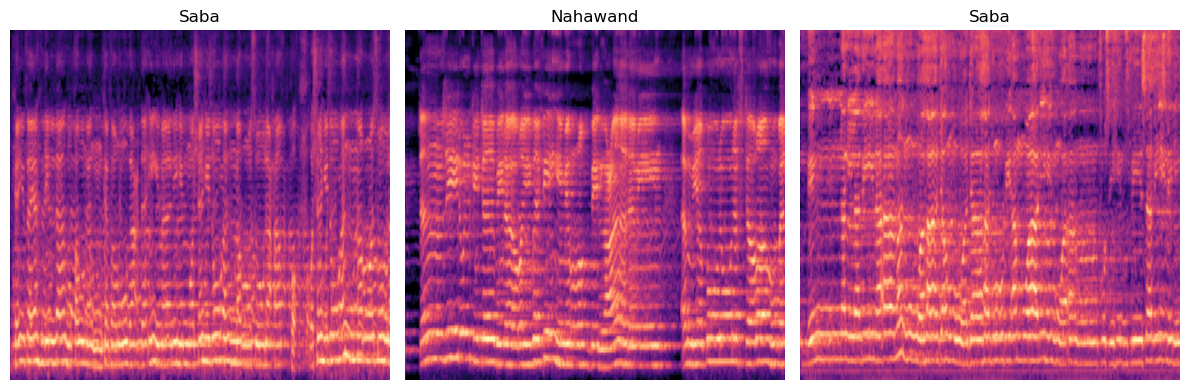

In [4]:
import matplotlib.pyplot as plt
import numpy as np, joblib, random, os

OUT_DIR = r"C:\Users\nabal\Documents\FYP\mel_spectrograms_v1"
le = joblib.load(os.path.join(OUT_DIR, "label_encoder.joblib"))
inv_le = {v:k for k,v in le.items()}

X = np.load(os.path.join(OUT_DIR, "X_train.npy"))
y = np.load(os.path.join(OUT_DIR, "y_train.npy"))

plt.figure(figsize=(12,4))
for i in range(3):  # show 3 random samples
    idx = random.randint(0, len(X)-1)
    plt.subplot(1,3,i+1)
    plt.imshow(X[idx], origin="lower", aspect="auto", cmap="magma")
    plt.title(inv_le[int(y[idx])])
    plt.axis("off")
plt.tight_layout()
plt.show()
